In [1]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl


In [5]:
ARTIFACT = "level_01_daily_total_sales_artifact"

In [6]:
import joblib

from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-08-30 13:51:46.275 | INFO     | src.data.split:load_data:322 - level_01_daily_total | target=sales | 1,941 filas | 191 features (9 categóricas)
2026-08-30 13:51:46.287 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 1,885 rows)
2026-08-30 13:51:46.288 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 28 rows)
2026-08-30 13:51:46.288 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 28 rows)
2026-08-30 13:51:46.491 | INFO     | src.data.split:split_data:384 - Features: 144 (0 categóricas)


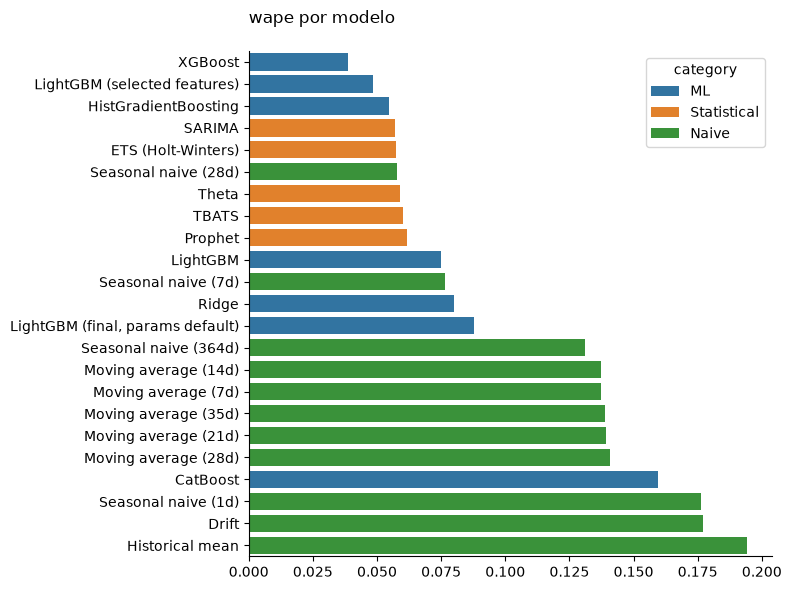

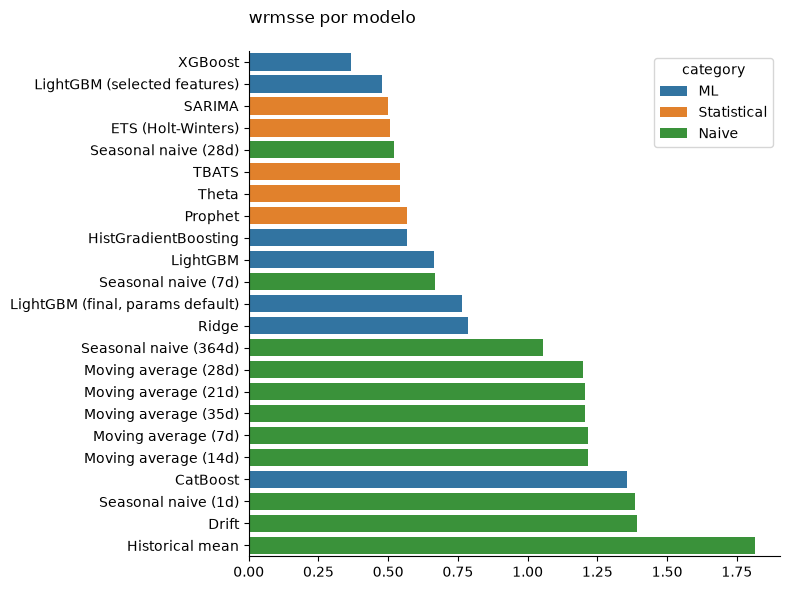

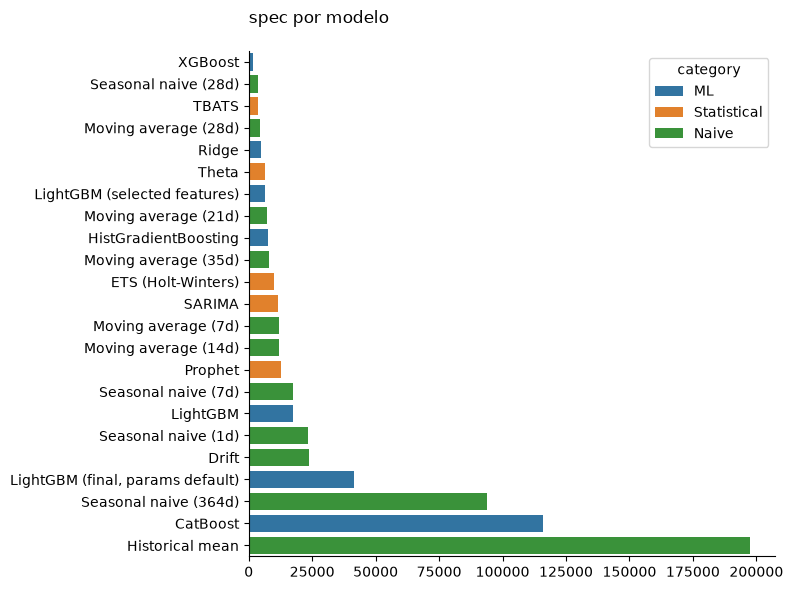

In [7]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [8]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                              feature  mean_abs_shap
54                              lag28    2622.180614
59                             lag364    1149.845805
24                    te_weekend_mean     832.594806
28                               lag1     592.003156
3                                 day     566.256864
..                                ...            ...
7                             dow_cos       3.594989
99     rolling_mean_lag6_window_size7       2.314156
9                           month_cos       0.763356
79     rolling_min_lag2_window_size14       0.733390
140  rolling_min_lag364_window_size91       0.340817

[144 rows x 2 columns]


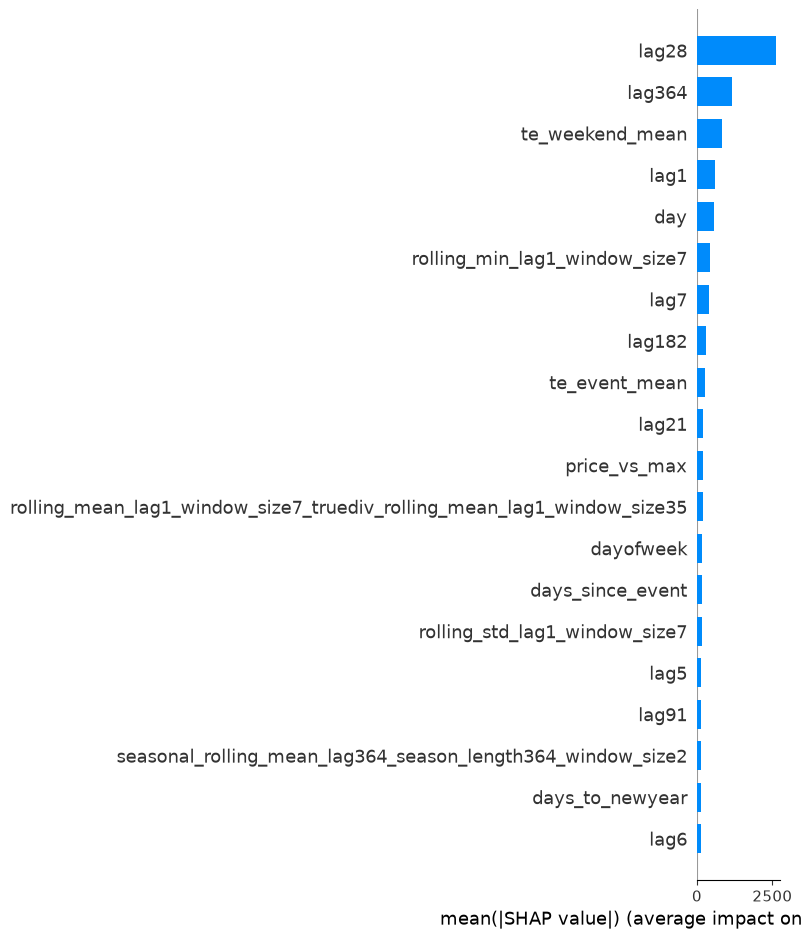

In [9]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


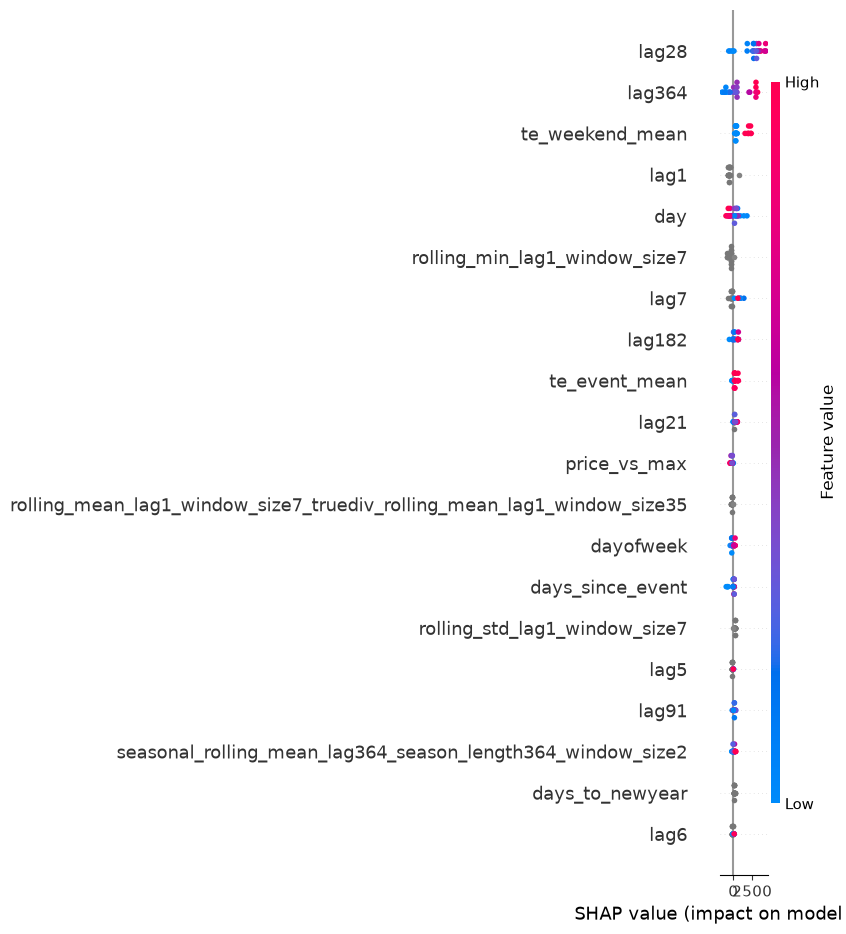

In [10]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [11]:
from src.evaluation import analizar_prediccion, plot_forecast, explain_prediction

In [12]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 12.84%
Test WRMSSE: 1.1341


In [13]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.to_clipboard()

In [14]:
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
TOTAL,28,28,1231764.0,1073550.0,158214.0,158214.0,3900976.0,1.0,0.128445,-0.128445,0.15084,28.0,1.218896,1.328679,84824.732143


In [15]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
TOTAL,28,28,1231764.0,1073550.0,158214.0,158214.0,3900976.0,1.0,0.128445,-0.128445,0.15084,28.0,1.218896,1.328679,84824.732143


In [16]:
df_metrics.nsmallest(5,'wrmsse')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
TOTAL,28,28,1231764.0,1073550.0,158214.0,158214.0,3900976.0,1.0,0.128445,-0.128445,0.15084,28.0,1.218896,1.328679,84824.732143


In [17]:
df_metrics.nlargest(5,'sales').T.round(3)

series_id,TOTAL
n_days,28.000
n_days_with_sales,28.000
sales,1231764.000
y_pred,1073550.000
error,158214.000
abs_error,158214.000
gross_sales,3900976.000
gross_sales_pct,1.000
wape,0.128
bias,-0.128


In [18]:
CASES = ['HOUSEHOLD_1_HOUSEHOLD_TX_3_TX', 'HOBBIES_1_HOBBIES_WI_1_WI','HOUSEHOLD_2_HOUSEHOLD_CA_2_CA']

df_metrics.to_clipboard(decimal=",", sep="\t")

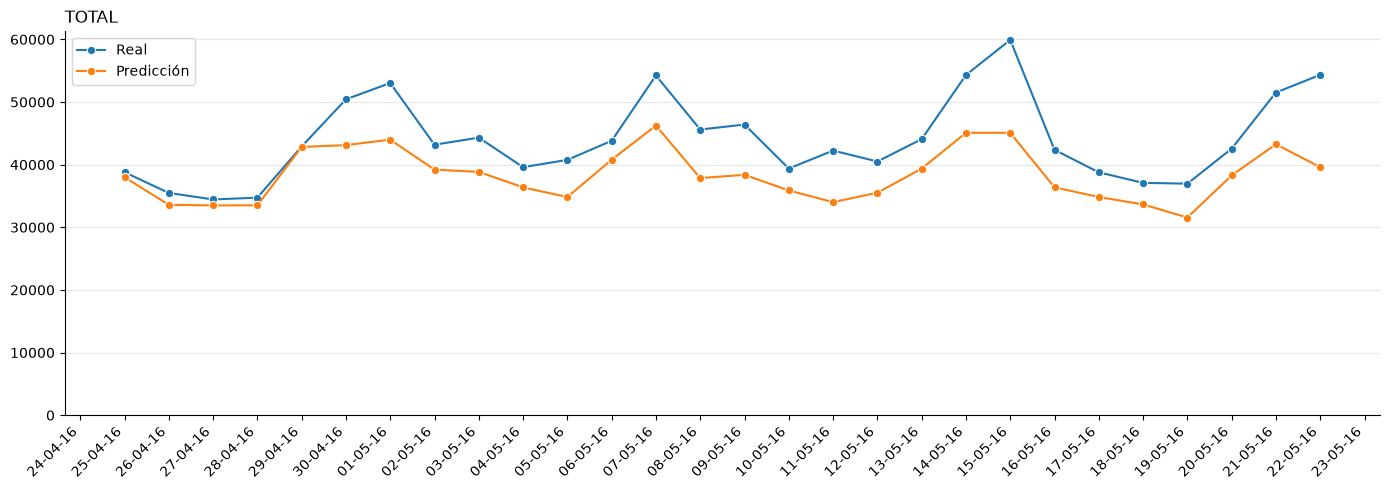

################################################## Date: 2016-04-29 00:00:00 ##################################################


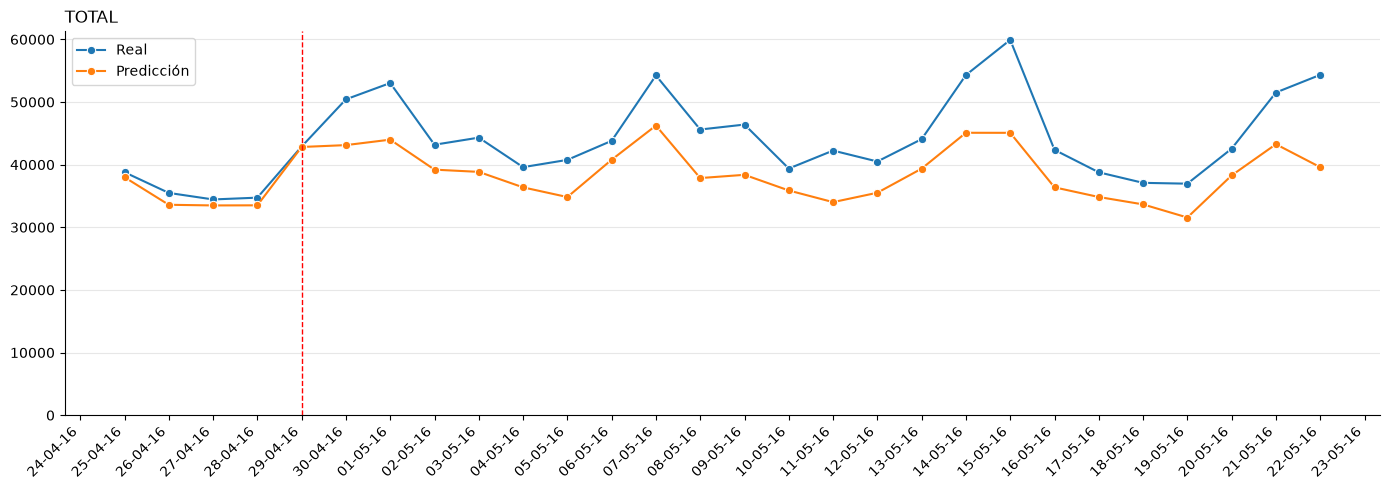

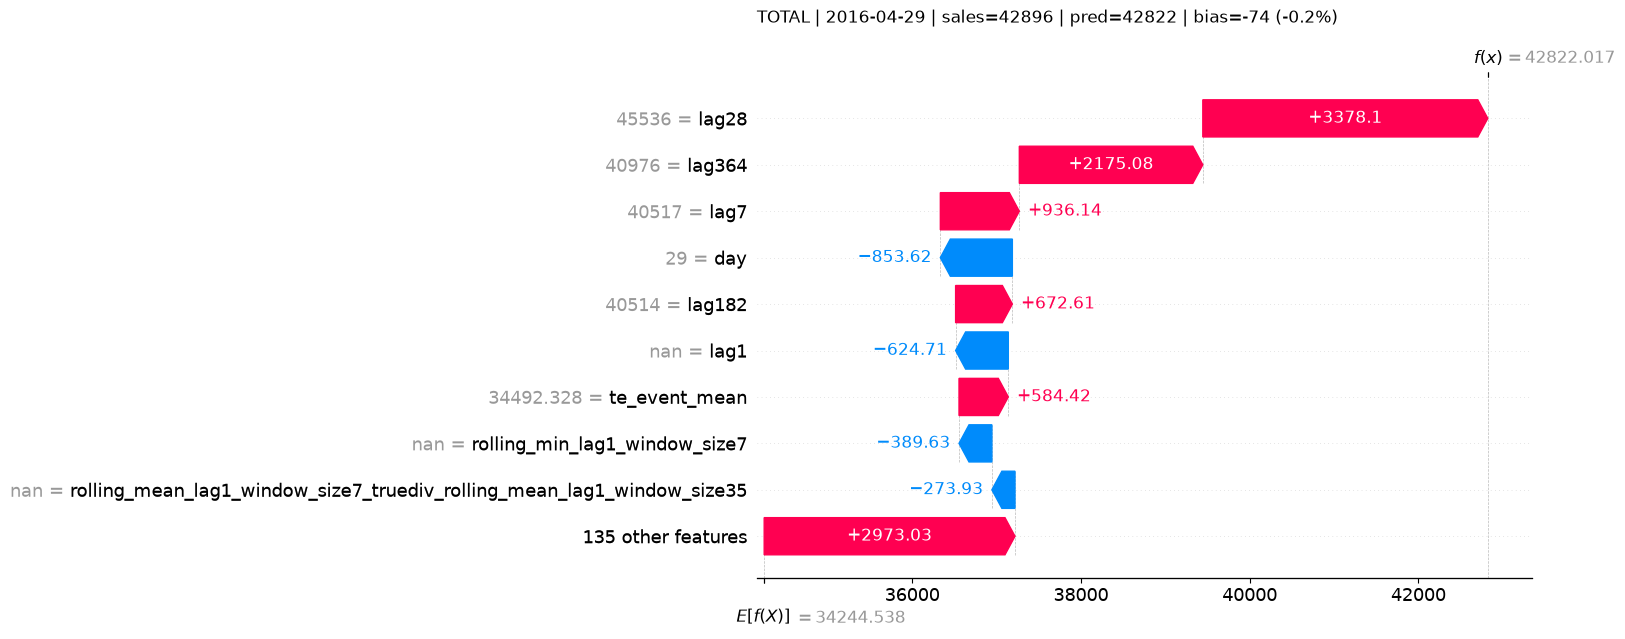

################################################## Date: 2016-04-25 00:00:00 ##################################################


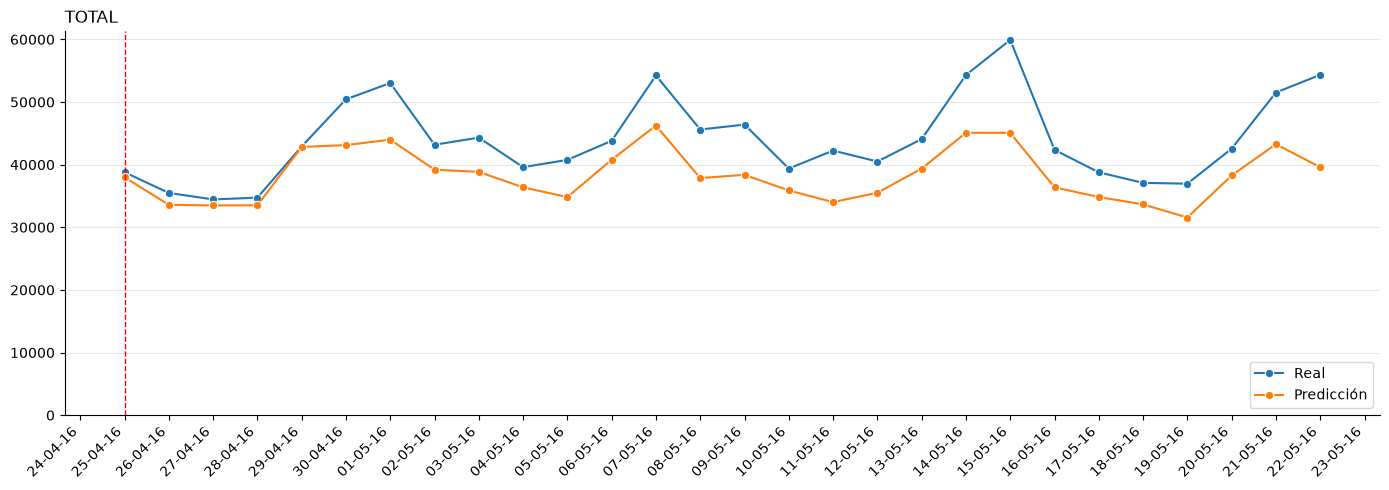

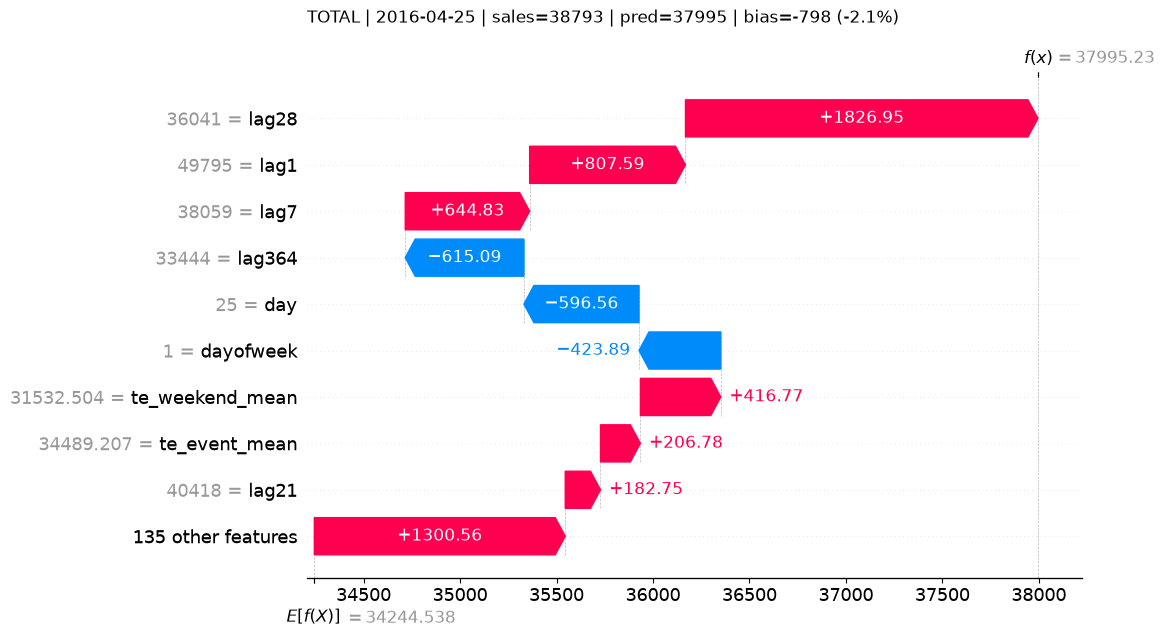

################################################## Date: 2016-04-27 00:00:00 ##################################################


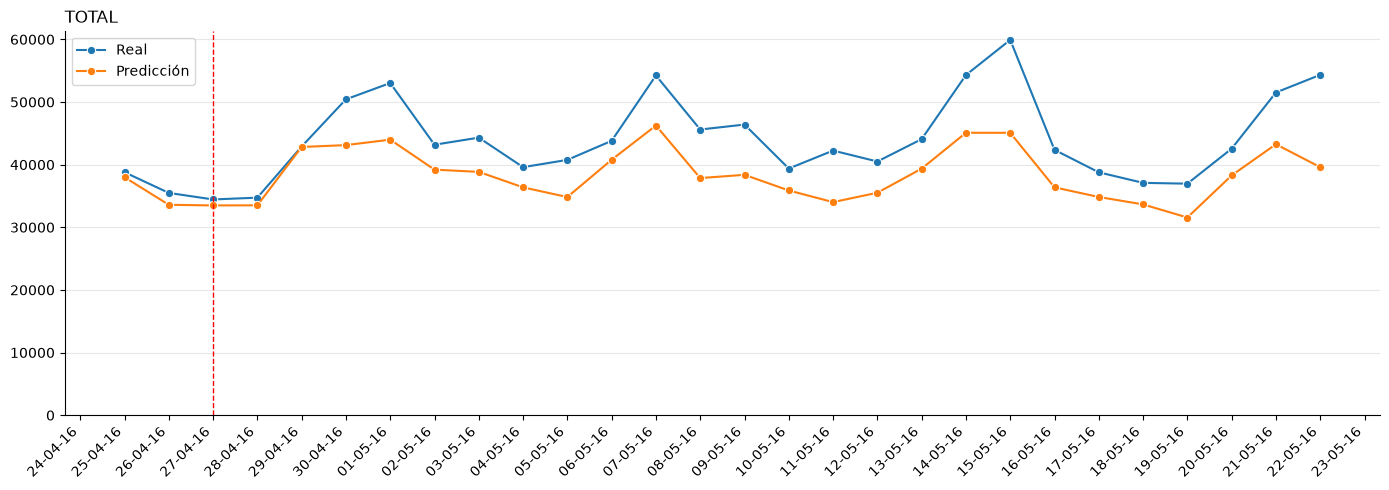

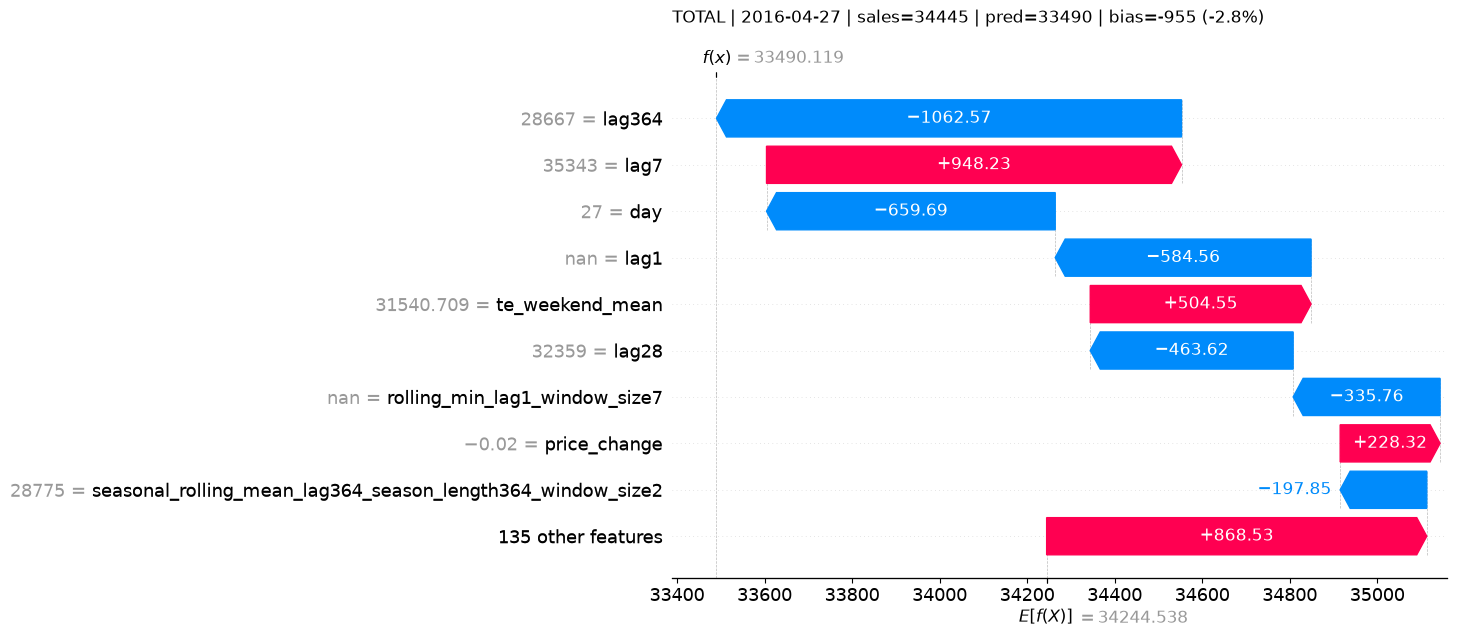

################################################## Date: 2016-05-22 00:00:00 ##################################################


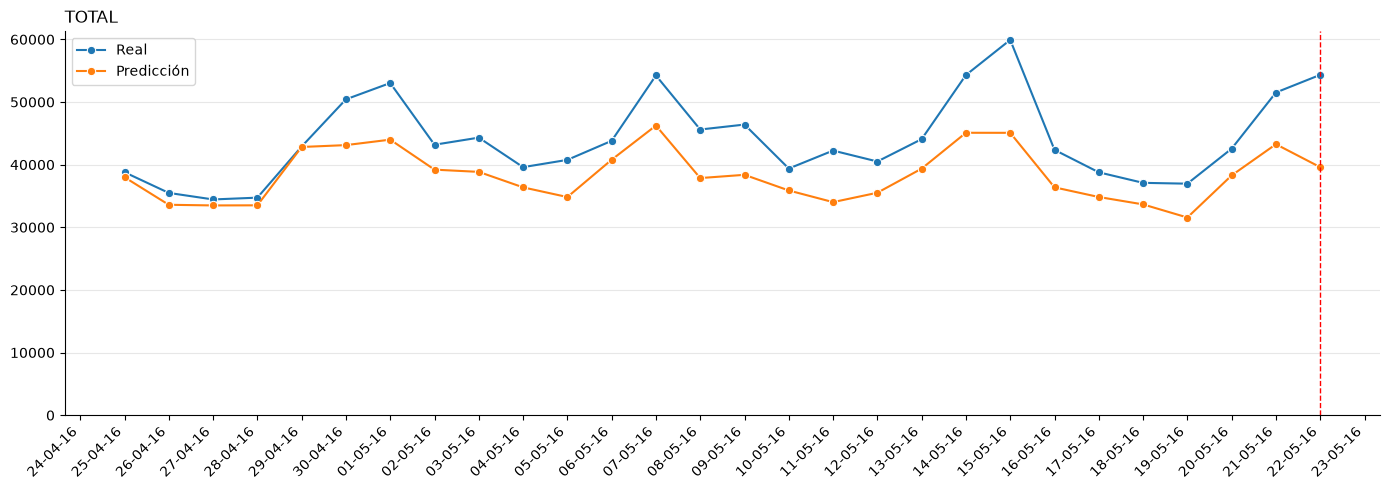

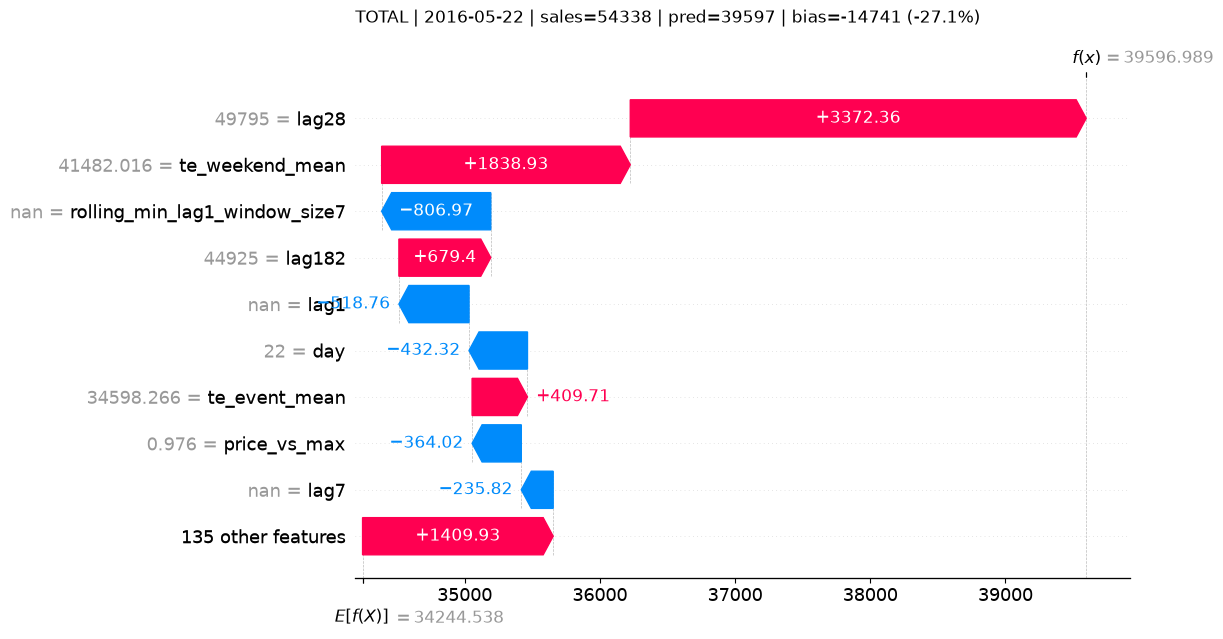

################################################## Date: 2016-05-15 00:00:00 ##################################################


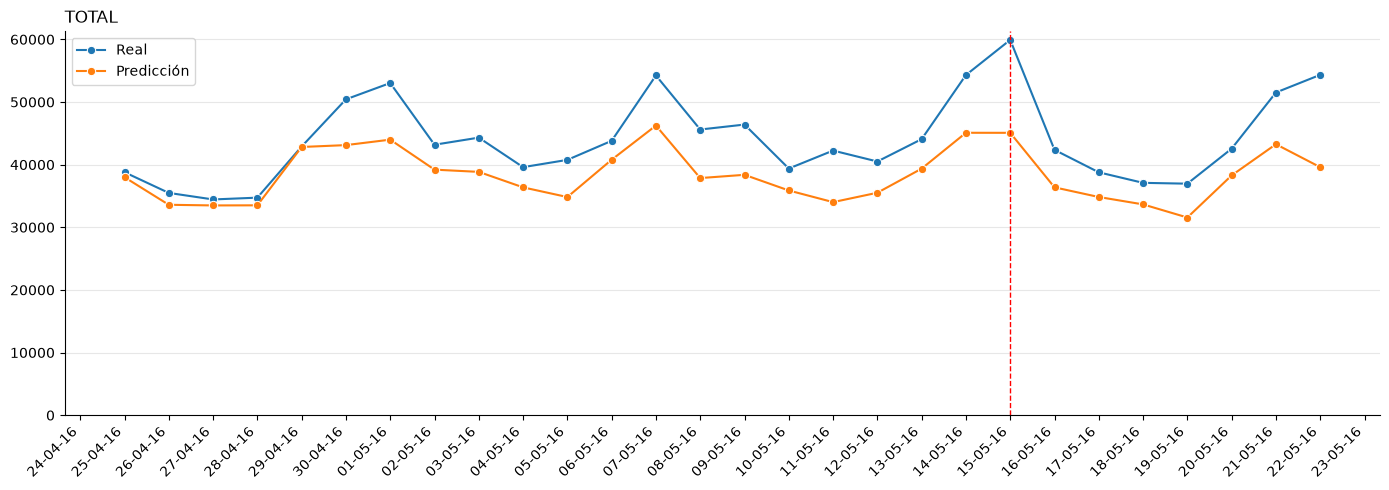

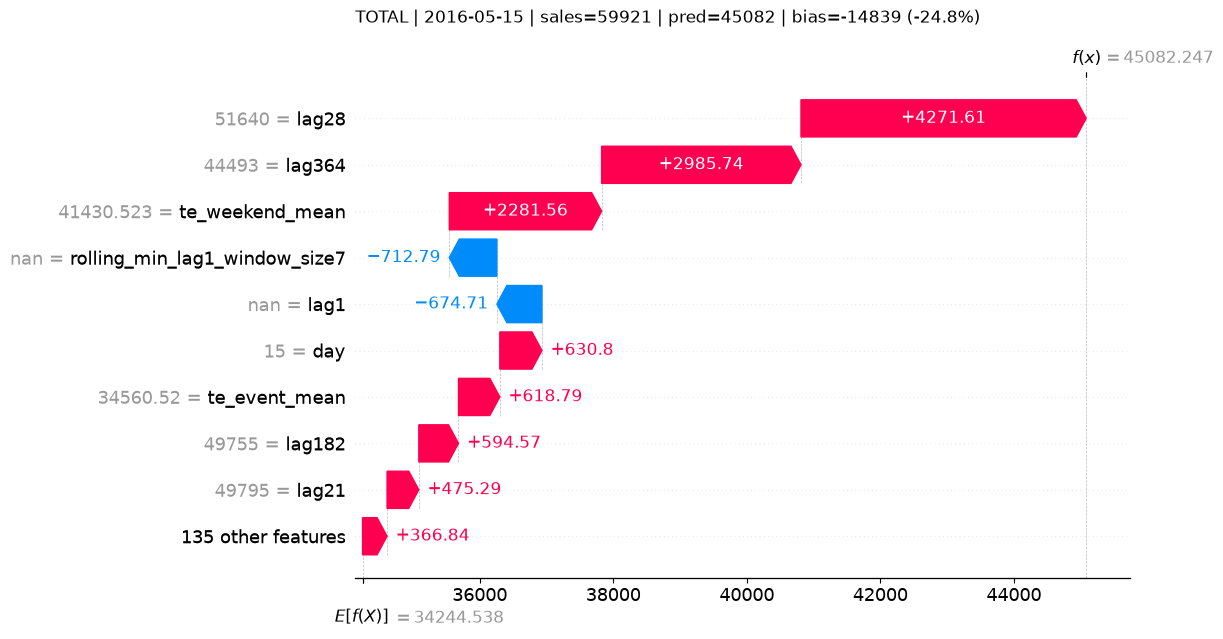

################################################## Date: 2016-05-11 00:00:00 ##################################################


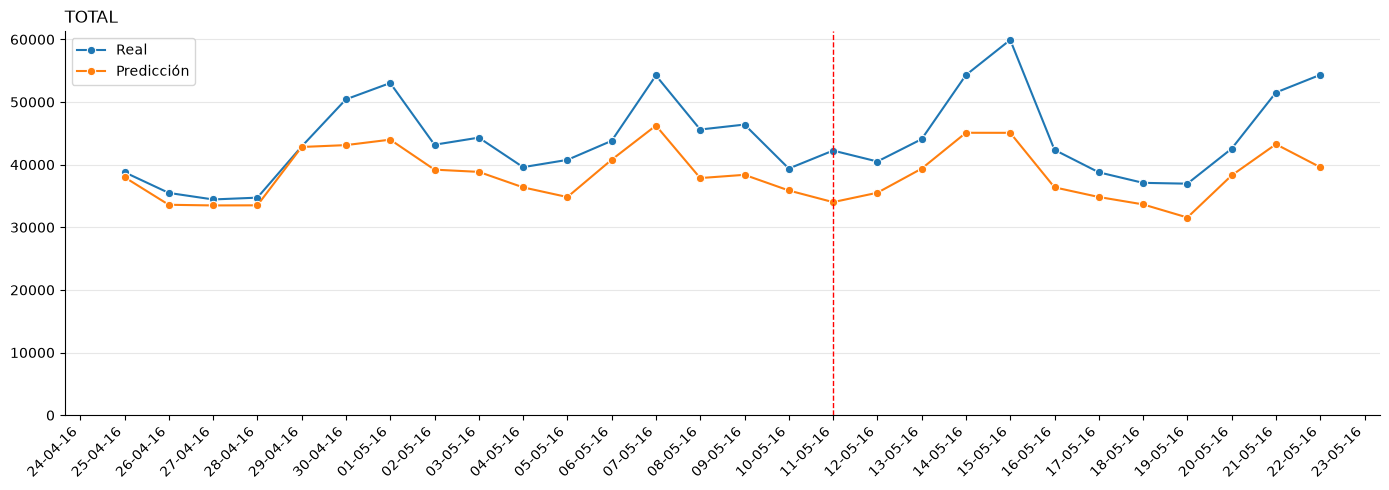

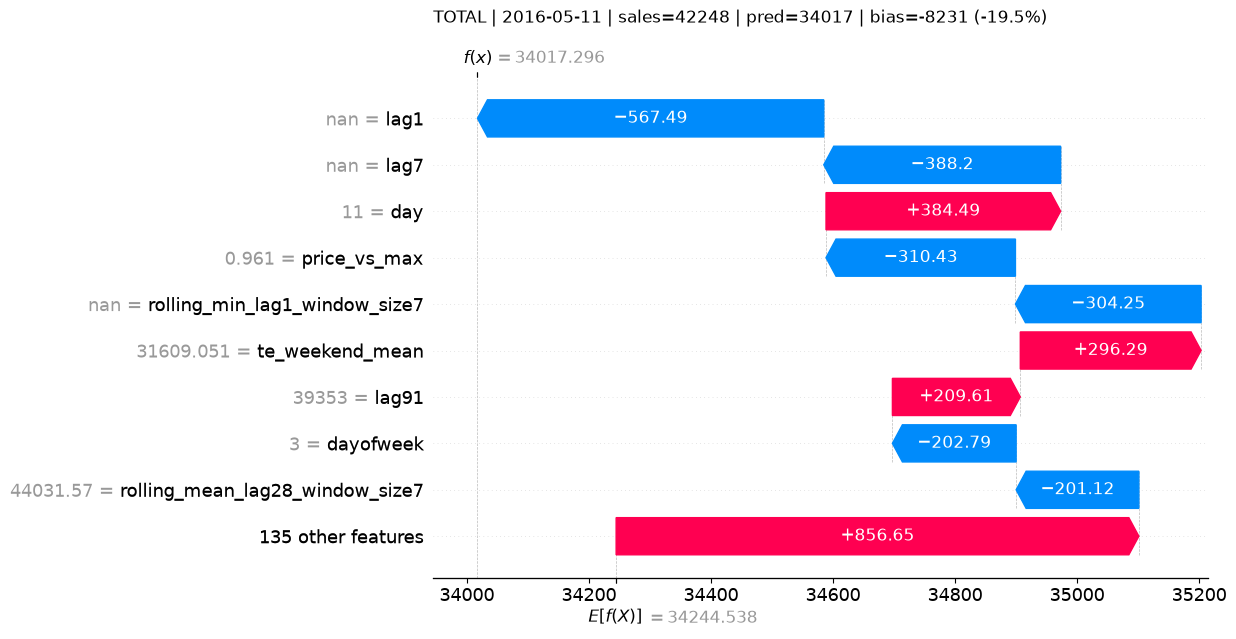

In [19]:
SERIES = 'TOTAL'

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(3, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(3, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)

for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)